# **Módulo 2 - Práticas de Preparação e Exploração de Dados - Exercicío Prático**
---

## 🏡 *Ames Housing* — Conjunto Base para Exercícios

Neste notebook, você trabalhará com uma versão reduzida do famoso dataset **Ames Housing**, que contém informações reais sobre casas e suas características.

#### Como começar?

1. **Execute a primeira célula** para carregar o dataset.
2. O conjunto de dados já vem filtrado com algumas colunas selecionadas — incluindo o preço da casa (*SalePrice*) e variáveis numéricas e categóricas importantes.
3. Siga as instruções ao longo do notebook — os comentários nas células indicam cada passo a ser realizado.
4. No final, utilize os resultados obtidos para responder às perguntas no espaço indicado no material do curso.


Execute a célula abaixo para começar.


In [ ]:
from sklearn.datasets import fetch_openml
import pandas as pd

ames = fetch_openml(name="house_prices", as_frame=True)
housing = ames.frame

cols = [
    "SalePrice",       # alvo
    "LotArea",         # tamanho do terreno
    "OverallQual",     # qualidade geral (1-10)
    "YearBuilt",       # ano de construção
    "GrLivArea",       # área habitável
    "GarageCars",      # vagas na garagem
    "TotalBsmtSF",     # área do porão
    "FullBath",        # número de banheiros completos
    "BedroomAbvGr",    # número de quartos
    "KitchenQual",     # qualidade da cozinha
    "Neighborhood"     # bairro
]

housing = housing[cols]

###  **Explorando os dados**

In [ ]:
# Use o comando info() para responder à pergunta

#### **1-Quais colunas devem ser codificadas com One-Hot Encoding?**

a) Apenas KitchenQual

b) Apenas Neighborhood

c) KitchenQual e Neighborhood

d) Nenhuma delas

(correta c)

### **Visualizando os dados**
Execute a célula abaixo para gerar três gráficos (A, B e C).
Depois disso, continue para a próxima célula e siga as intruções para responder à pergunta correspondente.

Cada um dos gráficos mostra a relação entre SalePrice (Preço de venda) e uma das variáveis:

* OverallQual (Qualidade geral)

* GrLivArea (Área habitável)

* GarageCars (Vagas na garagem)


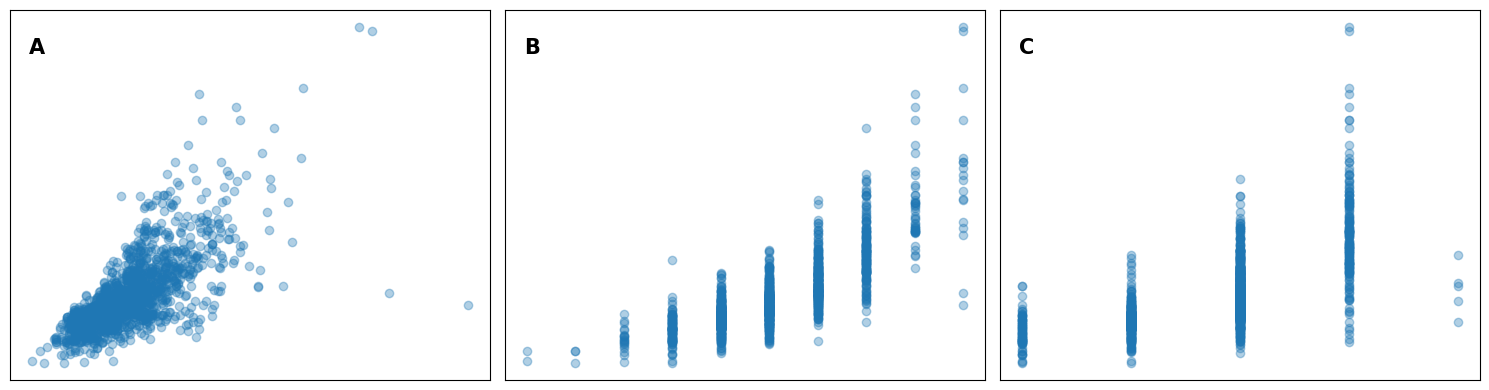

In [ ]:
import matplotlib.pyplot as _m
Z = housing

_x = ["GrLivArea", "OverallQual", "GarageCars"]
_y = "SalePrice"

f = lambda a, b: _m.scatter(a, b, alpha=0.35)

_m.figure(figsize=(15, 4))

for i, c in enumerate(_x):
    _m.subplot(1, 3, i+1)
    f(Z[c], Z[_y])
    _m.text(0.04, 0.88, chr(65+i), transform=_m.gca().transAxes,
            fontsize=15, fontweight="bold")
    _m.xticks([])
    _m.yticks([])

_m.tight_layout()
_m.show()



In [ ]:
# importe o scatter_matrix do pandas para gerar os gráficos necessários para responder a questão
import from pandas.plotting import
scatter_matrix(housing[["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "KitchenQual"]], figsize=(12, 10))

SyntaxError: invalid syntax (ipython-input-2389977390.py, line 2)

#### **2- Qual dos gráficos representa a correlação entre SalePice (Preço de venda) e GrLivArea (Área habitável)?**

a) Gráfico A.

b) Gráfico B.

c) Gráfico C.

d) Nenhum dos gráficos gerados.

(correta a)

Execute a célula a seguir

<Axes: >

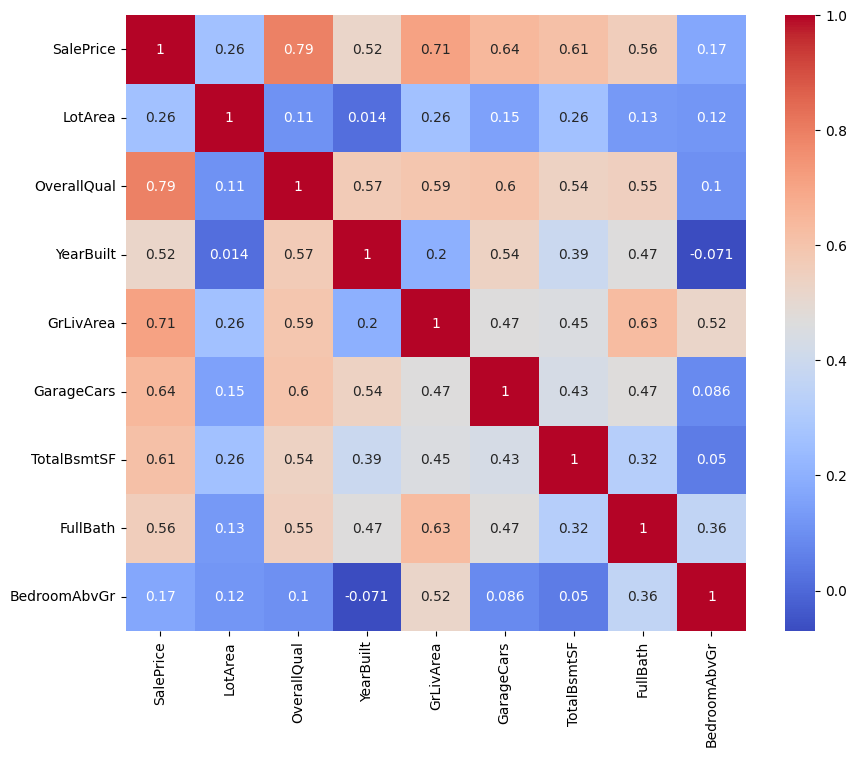

In [ ]:
corr_matrix = housing.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

#### **3 — Segundo a análise do heatmap, qual variável apresenta a maior correlação positiva com o preço de venda (SalePrice), desconsiderando a correlação da variável com ela mesma?**

a) GrLivArea

b) GarageCars

c) OverallQual

d) TotalBsmtSF

(correta c)

### **Tratando dados**

Execute a célula abaixo para aplicar o `MinMaxScaler` às variáveis numéricas do dataset.  
Depois, **aplique** e **observe** a saída do método `describe()` e responda à pergunta.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

housing_num = housing.drop(["KitchenQual", "Neighborhood"], axis=1)

scaler = MinMaxScaler()
housing_minmax = scaler.fit_transform(housing_num)

housing_minmax = pd.DataFrame(housing_minmax, columns=housing_num.columns)

# aplique o comando describe

#### **4- Qual coluna apresenta a menor média após a aplicação do MinMaxScaler?**

Escolha a alternativa correta com base na tabela gerada:

a) LotArea  
b) GarageCars  
c) BedroomAbvGr  
d) YearBuilt


(correta a)


Durante o pré-processamento de um conjunto de dados, foi identificada a presença de variáveis categóricas que precisavam ser convertidas para um formato numérico antes da modelagem.

Para isso, foi aplicado o **OneHotEncoder**, que cria uma coluna binária para cada categoria existente nessas variáveis.

Após a transformação, observa-se uma alteração clara na estrutura do dataset.

#### **5- O que normalmente acontece com o número de colunas após aplicar o OneHotEncoder?**

a) O número de colunas diminui, pois todas as categorias são condensadas em uma única variável numérica.  

b) O número de colunas permanece igual, já que apenas o tipo dos dados é convertido.  

c) O número de colunas aumenta, porque cada categoria gera uma nova coluna binária.  

d) O número de colunas diminui, pois categorias pouco frequentes são automaticamente removidas pelo encoder.


(correta c)

---

Neste módulo, você explorou o dataset Ames Housing, analisou variáveis importantes para prever preços de casas e praticou visualizações essenciais para compreender relações entre atributos e a variável-alvo.

Ao identificar tipos de dados, avaliar correlações e interpretar padrões nos gráficos, você deu mais um passo importante na construção de uma base sólida para modelagem preditiva.

No próximo módulo, vamos transformar essas análises em modelos que realmente aprendem com os dados.